In [1]:
from fastkaggle import *
from fastai.imports import *
from fastai.vision.all import *

In [2]:
trn_path=r"C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\PaddyDoc\train_images"
files=get_image_files(trn_path)

In [39]:
img=PILImage.create(files[0])
print(img.size)
img.to_thumb(256)

IndexError: list index out of range

In [5]:
img.size

(480, 640)

In [ ]:
from fastcore.parallel import *
def f(o): return PILImage.create(o).size
sizes=parallel(f,files,n_workers=8)
pd.Series(sizes).value_counts()

In [7]:
trn_path

'C:\\Users\\enesm\\OneDrive\\Masaüstü\\My_Deep_Learning_Journey\\PaddyDoc\\train_images'

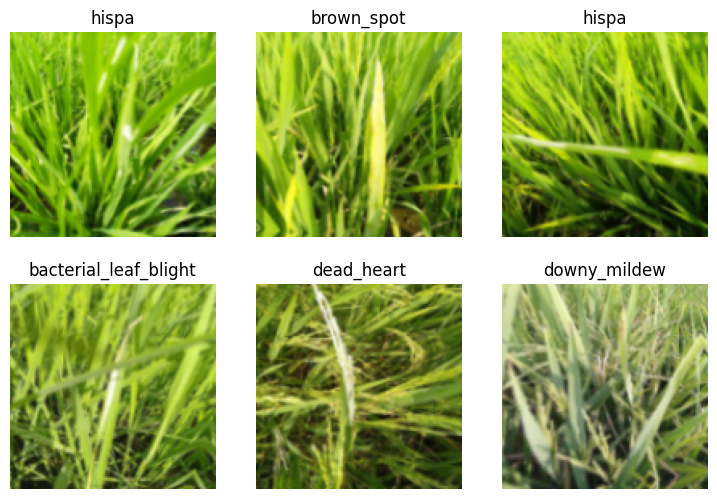

In [8]:
dls=ImageDataLoaders.from_folder(trn_path,valid_pct=0.20,
                                 item_tfms=Resize(128,method='squish'),
                                 batch_tfms=aug_transforms(size=128,min_scale=0.75))
dls.show_batch(max_n=6)

In [9]:
learn=vision_learner(dls,'resnet26d',metrics=error_rate, path='.',).to_fp16()

In [ ]:
learn.lr_find(suggest_funcs=(valley,slide))

In [ ]:
learn.fine_tune(3,0.01)

epoch,train_loss,valid_loss,error_rate,time
0,0.456619,1.509171,0.408938,00:57


epoch,train_loss,valid_loss,error_rate,time
0,0.396156,1.091014,0.284479,00:54
1,0.334677,0.990227,0.266699,00:55
2,0.245437,0.829696,0.233542,01:01


# Submitting to kaggle


In [12]:
ss=pd.read_csv(r"C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\PaddyDoc\sample_submission.csv")
ss

,image_id,label
0,200001.jpg,NaN
1,200002.jpg,NaN
2,200003.jpg,NaN
3,200004.jpg,NaN
4,200005.jpg,NaN
...,...,...
3464,203465.jpg,NaN
3465,203466.jpg,NaN
3466,203467.jpg,NaN
3467,203468.jpg,NaN


In [11]:
tst_files=get_image_files(r"C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\PaddyDoc\test_images").sorted()
tst_dl=dls.test_dl(tst_files)

In [ ]:
probs,_,idxs=learn.get_preds(dl=tst_dl,with_decoded=True)


In [ ]:
probs.shape

In [14]:
dls.vocab

['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']

In [16]:
mapping=dict(enumerate(dls.vocab))
mapping

{0: 'bacterial_leaf_blight',
 1: 'bacterial_leaf_streak',
 2: 'bacterial_panicle_blight',
 3: 'blast',
 4: 'brown_spot',
 5: 'dead_heart',
 6: 'downy_mildew',
 7: 'hispa',
 8: 'normal',
 9: 'tungro'}

In [ ]:
results=pd.Series(idxs.numpy(),name="idxs").map(mapping)

In [ ]:
results=pd.Series(idxs.numpy(),name="idxs")

In [ ]:
ss.label=results

In [ ]:
ss.to_csv('subm.csv',index=False)


# Going Faster

In [3]:
trn_path=Path('sml')
trn_path=r"C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\FastAi\sml"

In [4]:
resize_images(r"C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\PaddyDoc\train_images",dest=trn_path,max_size=256,recurse=True)

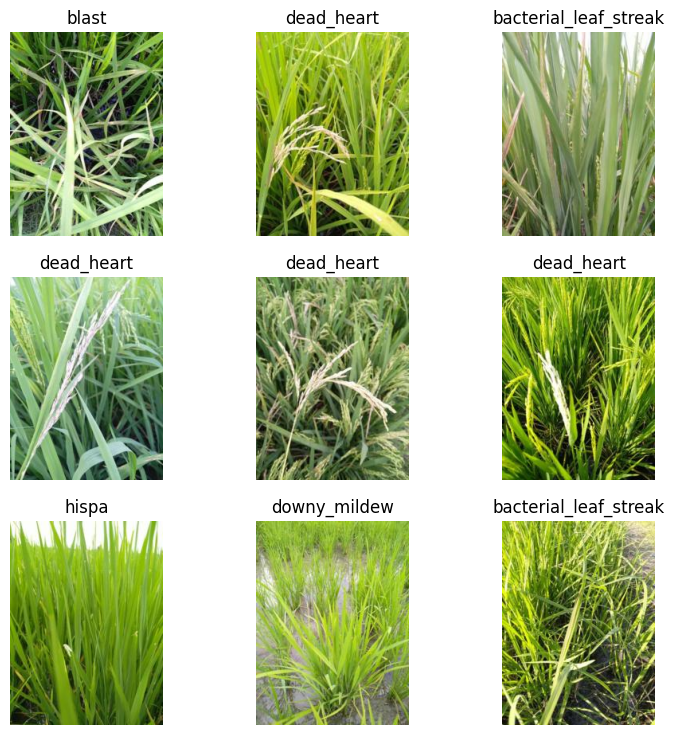

In [4]:
dls=ImageDataLoaders.from_folder(trn_path,valid_pct=0.20,
                                 item_tfms=Resize((256,192)))
dls.show_batch()

In [5]:
def train(arch,item,batch,epochs=5):
    dls=ImageDataLoaders.from_folder(trn_path,valid_pct=0.2,item_tfms=item,batch_tfms=batch)
    learn=vision_learner(dls,arch,metrics=error_rate).to_fp16()
    learn.fine_tune(epochs,0.01)
    return learn 

In [17]:
learn= train('resnet26d',item=Resize(192),batch=aug_transforms(size=128,min_scale=0.75))

epoch,train_loss,valid_loss,error_rate,time
0,1.923716,1.537593,0.483902,00:41


epoch,train_loss,valid_loss,error_rate,time
0,1.282183,0.980913,0.347429,00:33
1,0.978409,0.663601,0.233542,00:33
2,0.750920,0.467329,0.157617,00:33
3,0.529383,0.369920,0.124940,00:33
4,0.450336,0.340456,0.109563,00:33


## ConvNeXt Model

In [6]:
arch='convnext_small_in22k'

In [19]:
learn=train(arch,item=Resize(192,method='squish'),
            batch=aug_transforms(size=128,min_scale=0.75))

epoch,train_loss,valid_loss,error_rate,time
0,1.306378,0.935290,0.286401,00:56


epoch,train_loss,valid_loss,error_rate,time
0,0.655304,0.432936,0.141759,02:07
1,0.477807,0.340928,0.108602,01:56
2,0.321713,0.235941,0.074964,01:56
3,0.194604,0.162628,0.051418,01:57
4,0.134567,0.153905,0.047093,01:57


## Pre Processing Experiments

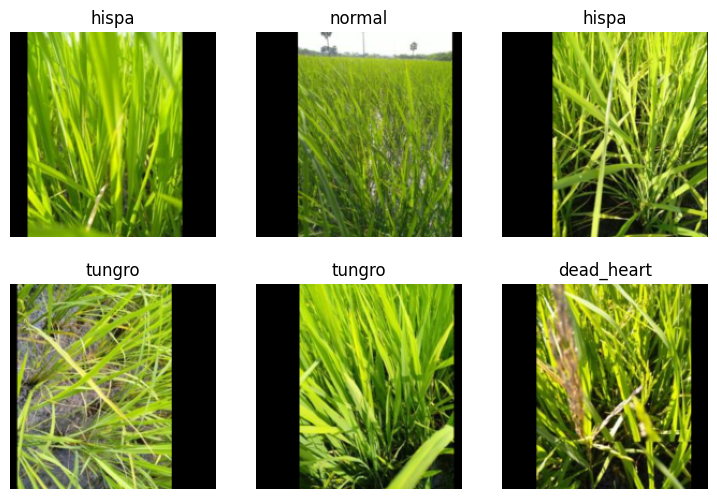

In [20]:
dls=ImageDataLoaders.from_folder(trn_path,valid_pct=0.2,
                                 item_tfms=Resize(192,method=ResizeMethod.Pad,pad_mode=PadMode.Zeros))
dls.show_batch(max_n=6)

In [7]:
learn=train(arch,item=Resize((256,192),method=ResizeMethod.Pad,pad_mode=PadMode.Zeros),
            batch=aug_transforms(size=(171,128),min_scale=0.75))

c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\_factory.py:114: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(


epoch,train_loss,valid_loss,error_rate,time
0,1.327294,0.923887,0.308506,00:28


epoch,train_loss,valid_loss,error_rate,time
0,0.692162,0.425903,0.136953,00:35
1,0.507357,0.315300,0.095147,00:35
2,0.350972,0.231559,0.075444,00:44
3,0.207697,0.168750,0.054781,00:48
4,0.147291,0.152427,0.047573,00:49


In [9]:
valid=learn.dls.valid
preds,targs = learn.get_preds(dl=valid)

In [22]:
preds[0]

tensor(1.0000)

In [11]:
error_rate(preds, targs)

TensorBase(0.0476)

In [23]:
tta_preds,_=learn.tta(dl=valid)

In [25]:
error_rate(tta_preds, targs)

TensorBase(0.0432)

In [7]:
learn=train(arch,epochs=12,item=Resize((480,360),method=ResizeMethod.Pad,pad_mode=PadMode.Zeros),
            batch=aug_transforms(size=(256,192),min_scale=0.75))

c:\Users\enesm\AppData\Local\Programs\Python\Python310\lib\site-packages\timm\models\_factory.py:114: UserWarning: Mapping deprecated model name convnext_small_in22k to current convnext_small.fb_in22k.
  model = create_fn(


epoch,train_loss,valid_loss,error_rate,time
0,1.204395,0.800885,0.238347,01:05


epoch,train_loss,valid_loss,error_rate,time
0,0.582877,0.356740,0.112926,02:24
1,0.433320,0.306458,0.090341,02:29
2,0.399971,0.288028,0.085536,02:28
3,0.334123,0.217011,0.062951,02:27
4,0.252343,0.194128,0.054781,02:21
5,0.200416,0.216940,0.057665,02:29
6,0.163606,0.153738,0.042768,02:24
7,0.094041,0.116455,0.030274,02:35
8,0.072029,0.115352,0.028832,02:30
9,0.055355,0.099611,0.028352,02:18


In [10]:
tta_preds,_=learn.tta(dl=valid)

In [11]:
error_rate(tta_preds, targs)

TensorBase(0.0250)

In [19]:
preds.shape

torch.Size([2081, 10])

In [26]:
idxs=preds.argmax(dim=1)
idxs

tensor([8, 5, 4,  ..., 4, 3, 7])

In [27]:
idxs.shape

torch.Size([2081])

In [29]:
vocab=np.array(learn.dls.vocab)
vocab

array(['bacterial_leaf_blight', 'bacterial_leaf_streak',
       'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart',
       'downy_mildew', 'hispa', 'normal', 'tungro'], dtype='<U24')

In [31]:
results = pd.Series(vocab[idxs], name="idxs")

In [32]:
results

0             normal
1         dead_heart
2         brown_spot
3       downy_mildew
4              blast
            ...     
2076      brown_spot
2077           blast
2078      brown_spot
2079           blast
2080           hispa
Name: idxs, Length: 2081, dtype: object

In [33]:
ss = pd.read_csv(r"C:\Users\enesm\OneDrive\Masaüstü\My_Deep_Learning_Journey\FastAi\PaddyDoc\sample_submission.csv")
ss['label'] = results
ss.to_csv('subm.csv', index=False)
